# Swiggy Restaurant Data Analysis

This notebook explores the Swiggy restaurant dataset which contains information about 8680 restaurants across multiple Indian cities. The goal is to understand pricing patterns, customer ratings, delivery performance and food type distribution across different cities.

## 1. Importing Libraries and Loading Data

First we import the required libraries and load the dataset into a pandas DataFrame.

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("swiggy.csv")
df.head()

,ID,Area,City,Restaurant,Price,Avg ratings,Total ratings,Food type,Address,Delivery time
0,211,Koramangala,Bangalore,Tandoor Hut,300,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59
1,221,Koramangala,Bangalore,Tunday Kababi,300,4.1,100,"Mughlai,Lucknowi",5Th Block,56
2,246,Jogupalya,Bangalore,Kim Lee,650,4.4,100,Chinese,Double Road,50
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57
4,249,Indiranagar,Bangalore,Nh8,350,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63


## 2. Dataset Overview

Here we take a quick look at the shape of the dataset to understand how many rows and columns we are working with.

In [28]:
print("Total rows:", df.shape[0])
print("Total Columns:", df.shape[1])

Total rows: 8680
Total Columns: 10


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8680 entries, 0 to 8679
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             8680 non-null   int64  
 1   Area           8680 non-null   str    
 2   City           8680 non-null   str    
 3   Restaurant     8680 non-null   str    
 4   Price          8680 non-null   int64  
 5   Avg ratings    8680 non-null   float64
 6   Total ratings  8680 non-null   int64  
 7   Food type      8680 non-null   str    
 8   Address        8680 non-null   str    
 9   Delivery time  8680 non-null   int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 1.3 MB


## 3. Checking Data Quality

Before starting the analysis it is important to check if there are any missing values or unexpected data types in the dataset.

In [30]:
df.isnull().sum()

ID               0
Area             0
City             0
Restaurant       0
Price            0
Avg ratings      0
Total ratings    0
Food type        0
Address          0
Delivery time    0
dtype: int64

In [31]:
df.dtypes

ID                 int64
Area                 str
City                 str
Restaurant           str
Price              int64
Avg ratings      float64
Total ratings      int64
Food type            str
Address              str
Delivery time      int64
dtype: object

The dataset has no null values across all 10 columns which means we can directly move into the analysis without any major cleaning steps.

## 4. Price Distribution

Let us look at how restaurant prices are distributed across the platform. The red dashed line represents the mean price.

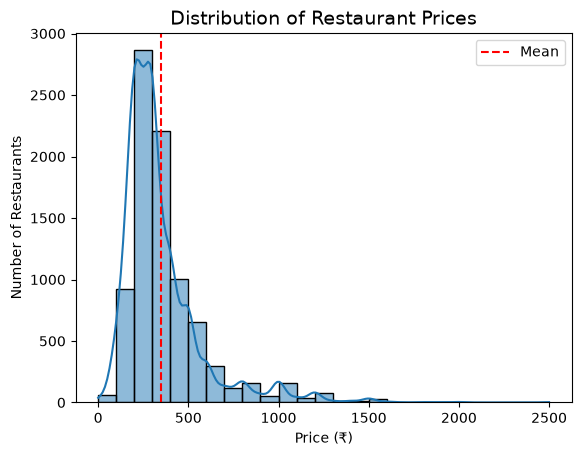

In [32]:
sns.histplot(
    data=df,
    x="Price",
    bins=25,
    kde=True
)
plt.axvline(df['Price'].mean(), color='red', linestyle='--', label='Mean')
plt.legend()
plt.title("Distribution of Restaurant Prices", fontsize=14)
plt.ylabel("Number of Restaurants")
plt.xlabel("Price (₹)")
plt.show()

Majority of restaurants fall in the ₹100 to ₹500 price range with a long right tail indicating a small number of premium priced restaurants. This suggests the platform primarily caters to budget and mid range dining options.

## 5. Price vs Average Rating

Now let us check if there is any relationship between the price of a restaurant and its average rating. The dashed lines represent the mean values for both axes.

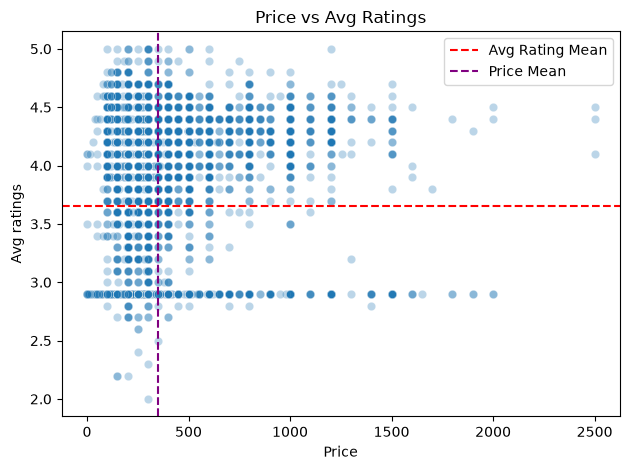

In [33]:
sns.scatterplot(
    data=df,
    x="Price",
    y="Avg ratings",
    alpha=0.3
)
plt.title("Price vs Avg Ratings")
plt.axhline(df['Avg ratings'].mean(), color="red", linestyle="--", label="Avg Rating Mean")
plt.axvline(df['Price'].mean(), color="purple", linestyle="--", label="Price Mean")
plt.legend()
plt.tight_layout()
plt.show()

Most restaurants are priced below the mean and rated above 3.7 which suggests that Swiggy's platform is dominated by affordable and well rated restaurants. There is no strong correlation between price and rating which means spending more does not guarantee a better dining experience.

## 6. Delivery Time Analysis

Here we look at which restaurants have the slowest and fastest average delivery times. This can help identify performance gaps on the platform.

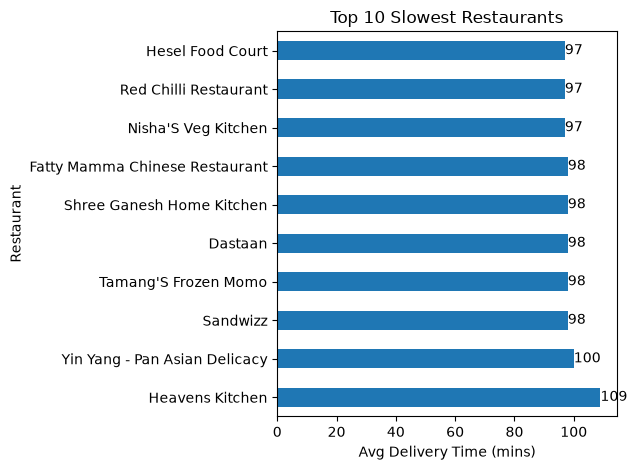

In [34]:
slow_deliver_performance = df.groupby('Restaurant')['Delivery time'].mean().sort_values(ascending=False).head(10)
ax = slow_deliver_performance.plot(kind='barh')
ax.bar_label(ax.containers[0])
plt.title("Top 10 Slowest Restaurants")
plt.xlabel("Avg Delivery Time (mins)")
plt.tight_layout()
plt.show()

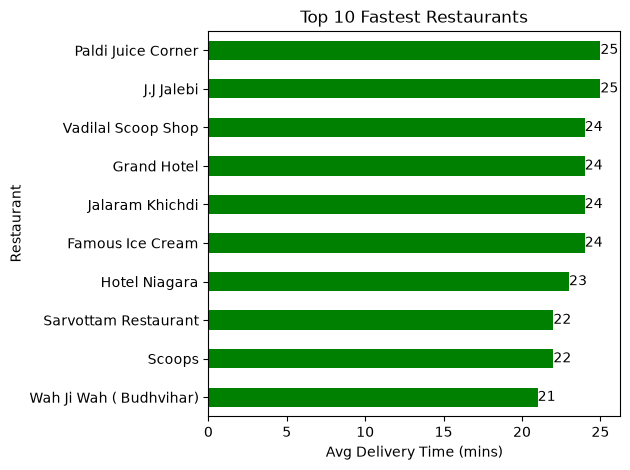

In [35]:
fast_delivery = df.groupby('Restaurant')['Delivery time'].mean().sort_values(ascending=True).head(10)
ax = fast_delivery.plot(kind='barh', color='green')
ax.bar_label(ax.containers[0])
plt.title("Top 10 Fastest Restaurants")
plt.xlabel("Avg Delivery Time (mins)")
plt.tight_layout()
plt.show()

There is a noticeable gap in delivery times across restaurants. Some restaurants take significantly longer which could impact customer satisfaction and ratings.

## 7. Food Type Analysis

The Food type column contains multiple cuisines separated by commas. We extract the primary food type from each entry to make the analysis cleaner and more meaningful.

In [36]:
df['Food type simple'] = df['Food type'].str.split(',').str[0]
df['Food type simple'].unique()

array(['Biryani', 'Mughlai', 'Chinese', 'North Indian', 'Rajasthani',
       'Mexican', 'Desserts', 'American', 'Bengali', 'Fast Food',
       'Kerala', 'Seafood', 'Arabian', 'Chinese  Thai  Asian',
       'Steakhouse', 'British', 'Thalis', 'Continental',
       'North Indian  South Indian',
       'Biryani  North Indian  Chinese  Tandoor',
       'North Indian  Chinese  Desserts  Continental  South Indian',
       'Ice Cream', 'South Indian', 'Tandoor', 'Punjabi', 'Andhra',
       'North Indian  Fast Food  Tandoor  Biryani  Kebabs  Snacks  Chinese',
       'Italian', 'Lebanese', 'Sweets', 'Ice Cream  Desserts', 'Salads',
       'Chinese  Italian  Desserts  Bakery  Fast Food',
       'Pastas  Beverages  Fast Food', 'Combo',
       'Chinese  Thai  Fast Food', 'Street Food', 'European',
       'Healthy Food', 'Goan', 'Desserts  Bakery', 'Indian', 'Bakery',
       'Snacks', 'Pizzas  Fast Food', 'Japanese',
       'Biryani  North Indian  Chinese',
       'Ice Cream Cakes  Desserts  Bakery 

By taking the first value from each food type entry we get a clean primary cuisine category for every restaurant. This makes grouping and visualization much easier.

## 8. City and Food Type Price Heatmap

This heatmap shows the average price of the top 10 most common food types across different cities. Darker cells indicate higher average prices.

In [37]:
pivot = pd.pivot_table(
    data=df,
    index="City",
    columns="Food type simple",
    values="Price",
    aggfunc="mean"
).fillna(0)
pivot

Food type simple,Afghani,American,American Beverages Fast Food,American Chinese Continental Desserts,American Chinese Indian,American Continental,American Continental Italian Pastas Snacks Desserts Beverages,American European Continental,American Fast Food,American Fast Food Beverages,...,Tandoor,Tandoor Arabian Grill Lucknowi Chinese Indian Beverages Mughlai Awadhi Lebanese,Tandoor Indian,Tandoor Mughlai Indian Biryani North Indian,Thai,Thalis,Tibetan,Tibetan Chinese Asian Snacks Continental Desserts Beverages,Tribal,Turkish
City,,,,,,,,,,,,,,,,,,,,,
Ahmedabad,0.0,372.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,70.000000,0.0,0.0,0.0,0.000000,205.000000,250.000000,0.0,0.0,0.0
Bangalore,0.0,589.523810,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,300.000000,0.0,0.0,0.0,375.000000,266.666667,250.000000,0.0,0.0,325.0
Chennai,400.0,354.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,400.000000,0.0,0.0,0.0,1216.666667,0.000000,300.000000,0.0,0.0,0.0
Delhi,0.0,416.666667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,283.333333,0.0,0.0,0.0,0.000000,200.000000,350.000000,0.0,0.0,0.0
Hyderabad,850.0,340.909091,0.0,0.0,0.0,0.0,0.0,0.0,350.0,0.0,...,500.000000,0.0,0.0,0.0,0.000000,0.000000,400.000000,0.0,0.0,500.0
Kolkata,300.0,394.117647,0.0,450.0,0.0,0.0,350.0,0.0,350.0,300.0,...,312.500000,0.0,0.0,0.0,600.000000,275.000000,271.428571,0.0,1200.0,0.0
Mumbai,0.0,450.000000,350.0,0.0,300.0,900.0,0.0,500.0,300.0,0.0,...,0.000000,220.0,600.0,500.0,1150.000000,200.000000,300.000000,400.0,0.0,1550.0
Pune,0.0,439.583333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,350.000000,0.0,0.0,0.0,1600.000000,285.000000,266.666667,0.0,0.0,0.0
Surat,0.0,387.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,300.000000,0.0,0.0,0.0,0.000000,210.000000,0.000000,0.0,0.0,0.0


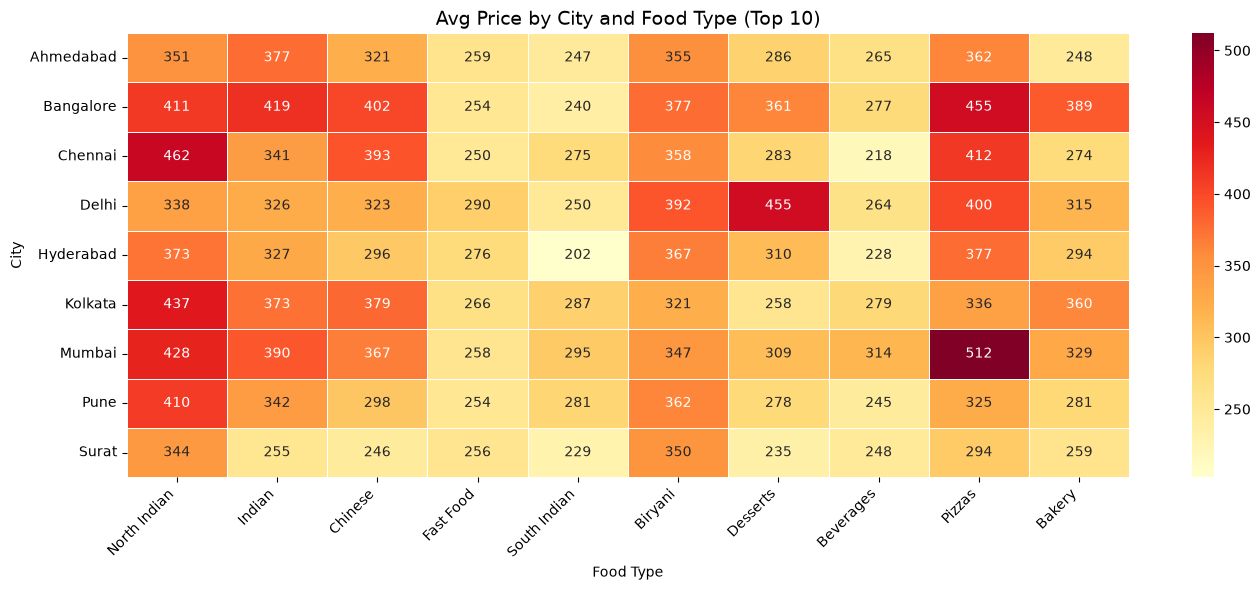

In [38]:
top10 = df['Food type simple'].value_counts().head(10).index
pivot_top10 = pivot[top10]

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_top10,
            annot=True,
            fmt='.0f',
            cmap='YlOrRd',
            linewidths=0.5)
plt.title("Avg Price by City and Food Type (Top 10)", fontsize=14)
plt.xlabel("Food Type")
plt.ylabel("City")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Mumbai and Bangalore tend to be the most expensive cities across most food categories while Surat and Ahmedabad are generally more affordable. Pizza is consistently the most expensive food type across cities.

## 9. Top 10 Highest Rated Restaurants

To avoid bias from restaurants with very few reviews we only consider restaurants with more than 100 total ratings.

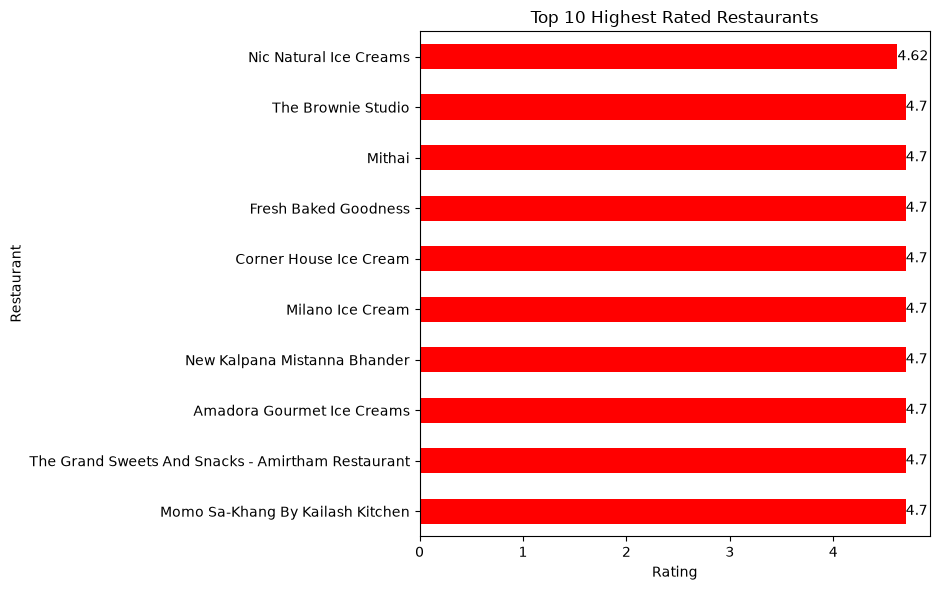

In [51]:
plt.figure(figsize=(9.5,6))
ax = df[df["Total ratings"] > 100].groupby("Restaurant")["Avg ratings"].mean().sort_values(ascending=False).head(10).plot(kind="barh", color='red')
ax.bar_label(ax.containers[0])
plt.xlabel("Rating")
plt.title("Top 10 Highest Rated Restaurants")
plt.tight_layout()
plt.show()

By filtering restaurants with more than 100 ratings we ensure that the top rated list reflects genuinely popular and consistent performers rather than restaurants with just a few reviews.

## 10. Correlation Heatmap

This heatmap shows how the numeric variables in the dataset relate to each other. Values close to 1 or -1 indicate strong correlation while values near 0 indicate no relationship.

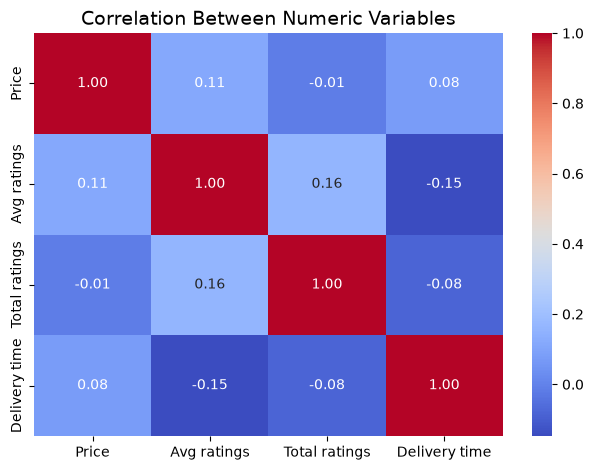

In [40]:
sns.heatmap(
    df[['Price', 'Avg ratings', 'Total ratings', 'Delivery time']].corr(),
    annot=True,
    cmap="coolwarm",
    fmt='.2f'
)
plt.title("Correlation Between Numeric Variables", fontsize=14)
plt.tight_layout()
plt.show()

The correlation heatmap confirms that price has very little impact on ratings or delivery time. Total ratings and avg ratings show a slight positive relationship which makes sense as more popular restaurants tend to maintain their quality.

## 11. Food Type Distribution

This donut chart shows what percentage of restaurants belong to each of the top 8 primary cuisine categories on Swiggy.

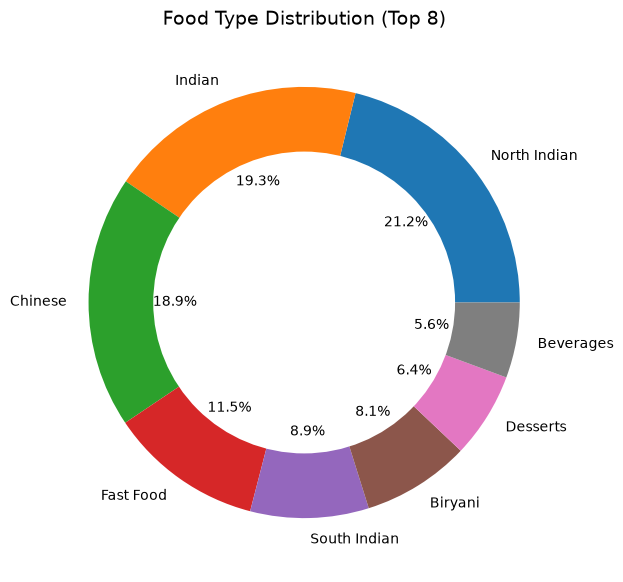

In [41]:
fig, ax = plt.subplots(figsize=(7, 7))
df['Food type simple'].value_counts().head(8).plot(kind="pie", autopct="%1.1f%%", ax=ax)

center_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_patch(center_circle)
plt.title("Food Type Distribution (Top 8)", fontsize=14)
plt.ylabel('')
plt.show()

North Indian cuisine dominates the platform followed by Chinese and South Indian. This reflects the general food preferences across major Indian cities where Swiggy operates.

## 12. Restaurant Count by City

Finally let us see how many restaurants are listed on Swiggy from each city in the dataset.

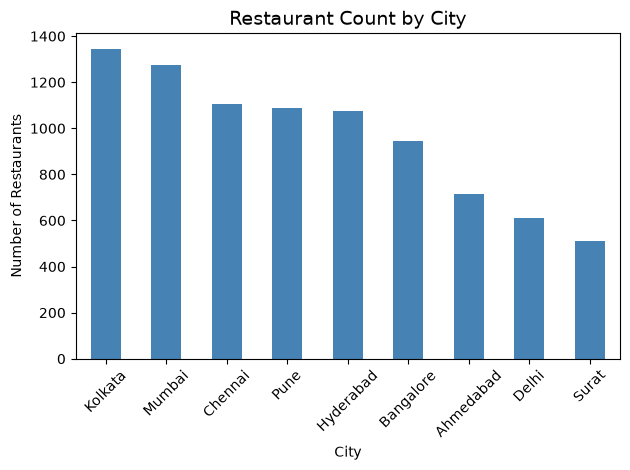

In [42]:
df['City'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Restaurant Count by City", fontsize=14)
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Some cities have significantly more restaurant listings than others. This could reflect the actual market size of Swiggy in those cities or simply the availability of data.

## Summary

After analyzing the Swiggy dataset across 8680 restaurants and 9 cities here are the key findings from this project.

Most restaurants on Swiggy are priced between ₹100 and ₹500 which shows the platform mainly serves budget and mid range customers. There is no strong link between price and rating so paying more does not always mean better food or service. Mumbai and Bangalore have the highest average prices across food types while Surat and Ahmedabad are more budget friendly. North Indian cuisine is the most common food type listed on the platform. Delivery time varies quite a bit between restaurants which is something that directly affects customer experience and could be explored further.